In [106]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

### Business Understanding
The goal is to build a machine learning model to distinguish possible phishing sites. We will build two different models, one using decision trees and the other using random forests.

### Data Understanding
The data is imported from `https://archive.ics.uci.edu/dataset/327/phishing+websites` and is imported via python ucimlrepo. The data consists of 30 features considered effective to predict phishing websites. A feature that is considered suspicious is marked as 0 (neutral) on the dataset, -1 is marked as phishing and 1 as legit. 

In [107]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
phishing_websites = fetch_ucirepo(id=327) 
  
# data (as pandas dataframes) 
X = phishing_websites.data.features 
y = phishing_websites.data.targets 

X.head(10)

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,1,-1,1,-1,-1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,1,-1,-1,-1,1,0,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,0,-1,1,0,1
8,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,1,-1,1,1,1,0,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,1,-1,0,-1,1,0,1


### Data Preparation
The dataset is clean and has no missing values according to ucimlrepo. We split the training data in the training set and testing set `75/25`.

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20) # extract test set
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8291, 30) (2764, 30) (8291, 1) (2764, 1)


### Modeling
After splitting the data to our training- and testset, we proceed to build the actual models.

#### Decision tree
First we start by training the decision tree model. We used the `ccp_alpha` parameter to prune the tree slightly in order to reduce the complexity of the tree and prevent overfitting.

In [109]:
# building the model classifier
dt_model = DecisionTreeClassifier(
    random_state=20,
    ccp_alpha=0.01
)
dt_model.fit(X_train, y_train)

print(dt_model.classes_)

[-1  1]


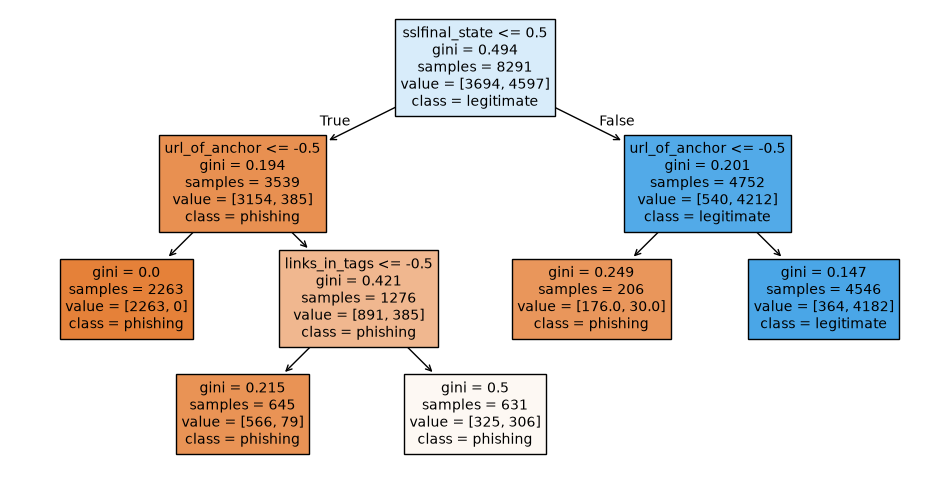

In [110]:
# plotting the decision tree
dt_fig = plt.figure(figsize = (12, 6))
plot_tree(dt_model, feature_names = X.keys(), class_names = ['phishing', 'legitimate'], filled = True, fontsize = 10)
plt.show()

#### Random forest

The second model we used was the random forest. We used the exact same training- and testset as the decision tree model. We started off by flattening the y values since the random forest model requires one dimensional array as input.

In [111]:
y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

The first random forest model we built was with base/untuned values.

In [112]:
rf_model = RandomForestClassifier(
    random_state=20,
    n_estimators=100,
    bootstrap=True,
    max_samples=0.7,
    max_features=0.75
)
rf_model.fit(X_train, y_train_1d)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.75
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",20
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of th

We then tuned the model by adjusting hyperparameters.

In [113]:
rf_model_tuned = RandomForestClassifier(
    random_state=20,
    n_estimators=200,
    bootstrap=True,
    max_samples=0.8,
    max_features=0.8,
)
rf_model_tuned.fit(X_train, y_train_1d)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",20
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.8
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the

### Evaluation

After training the models, we evaluated the performance of all models. We primarily used confusion matrices and accuracy scores as tools of evaluation.

#### Decision tree

We start by evaluating the decision tree. We used the testset to predict the legimitacy and formed a confusion matrix. We also calculated the accuracy, precision and recall scores.

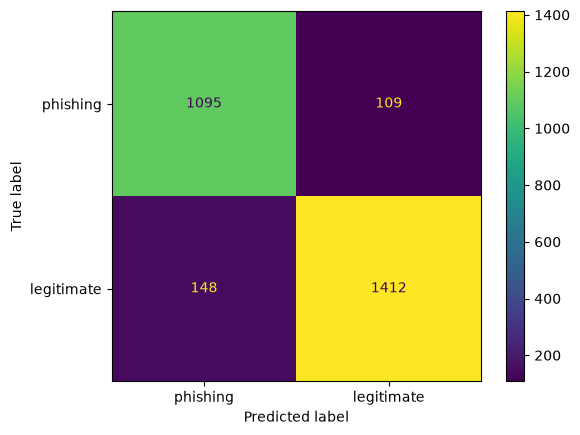

In [114]:
# predict, form confusion matrix and plot it
dt_predict = dt_model.predict(X_test)
dt_conf_matrix = confusion_matrix(y_test, dt_predict)
ConfusionMatrixDisplay(dt_conf_matrix, display_labels=['phishing', 'legitimate']).plot()

In [115]:
dt_accuracy = accuracy_score(y_test, dt_predict)
dt_precision = precision_score(y_test, dt_predict, pos_label=-1)
dt_recall = recall_score(y_test, dt_predict, pos_label=-1)

print("Decision tree metrics:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")


Decision tree metrics:
Accuracy: 0.9070
Precision: 0.8809
Recall: 0.9095


We notice that the model has pretty good accuracy, but the precision and recall scores are not as good. The model correctly predicts phishing sites, but it also predicts lots of false negatives, which is definitely not ideal.

#### Random forest (base values)
Next we evaluate the random forest model with the base (untuned) values. The procedure here is the same as the decision tree.

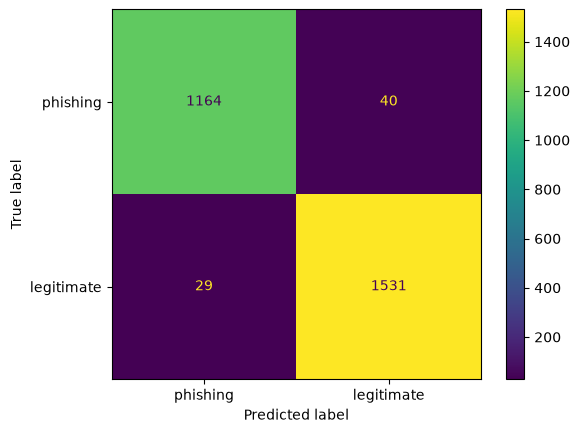

In [116]:
rf_predict = rf_model.predict(X_test)
rf_conf_matrix = confusion_matrix(y_test, rf_predict)
ConfusionMatrixDisplay(rf_conf_matrix, display_labels=['phishing', 'legitimate']).plot()

In [117]:
rf_accuracy = accuracy_score(y_test, rf_predict)
rf_precision = precision_score(y_test, rf_predict, pos_label=-1)
rf_recall = recall_score(y_test, rf_predict, pos_label=-1)

print("Random forest metrics (base values):")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")

Random forest metrics (base values):
Accuracy: 0.9750
Precision: 0.9757
Recall: 0.9668


We instantly notice that the random forest model performs much better than the simple decision tree model. This is expected, as per the core nature of the random forest model.

#### Random forest (tuned values)

We also tried to tune the random forest model by adjusting hyperparameters for improving the performance. In this case, we increased the `n_estimators`, `max_samples` and `max_features` parameters, which in theory should improve the model's stability and performance.

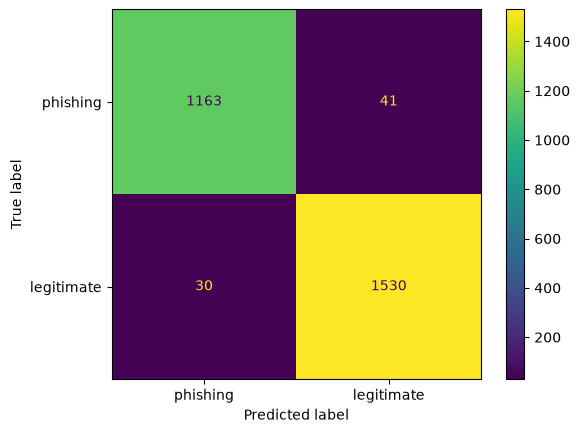

In [118]:
rf_t_predict = rf_model_tuned.predict(X_test)
rf_t_conf_matrix = confusion_matrix(y_test, rf_t_predict)
ConfusionMatrixDisplay(rf_t_conf_matrix, display_labels=['phishing', 'legitimate']).plot()

In [119]:
rf_t_accuracy = accuracy_score(y_test, rf_t_predict)
rf_t_precision = precision_score(y_test, rf_t_predict, pos_label=-1)
rf_t_recall = recall_score(y_test, rf_t_predict, pos_label=-1)

print("Random forest metrics (tuned values):")
print(f"Accuracy: {rf_t_accuracy:.4f}")
print(f"Precision: {rf_t_precision:.4f}")
print(f"Recall: {rf_t_recall:.4f}")

Random forest metrics (tuned values):
Accuracy: 0.9743
Precision: 0.9749
Recall: 0.9659


We can see that the tuned model actually performs slightly worse than the base model. So in this spesific case, increasing the number of trees, maximum samples and features did not improve performance.

### Deployment

Out of the three tested models, the random forest with base values performed the best. This model could for example be used in some sort of system for detecting phishing websites from legitimate ones. Though there was still some false positives, the model performed good enough to be used as a sort of "first line of defense" for flagging possible phishing sites.